# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [692]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os

In [693]:
IMAGE_WIDTH=64
IMAGE_HEIGHT=64
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 64
EPOCHS = 100

In [694]:
ROOT_PATH = "C:/Users/Asier/Downloads/clasificador_paisajes/"

TRAIN_PATH = ROOT_PATH+ "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

In [695]:
folders = os.listdir(TRAIN_PATH)

In [696]:
folders

['buildings',
 'ej_paisaje.h5',
 'forest',
 'glacier',
 'mountain',
 'sea',
 'street']

In [697]:
filenames = []
categories = []

for folder in folders:
    folder_path = os.path.join(TRAIN_PATH, folder)

    # Solo carpetas (clases)
    if not os.path.isdir(folder_path):
        continue

    # Recorremos imágenes de la carpeta
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        filenames.append(file)
        categories.append(folder)

df = pd.DataFrame({
    "filename": filenames,
    "category": categories
})


In [698]:
df.head()

,filename,category
0,0.jpg,buildings
1,10006.jpg,buildings
2,1001.jpg,buildings
3,10014.jpg,buildings
4,10018.jpg,buildings


In [699]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14034 entries, 0 to 14033
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  14034 non-null  object
 1   category  14034 non-null  object
dtypes: object(2)
memory usage: 219.4+ KB


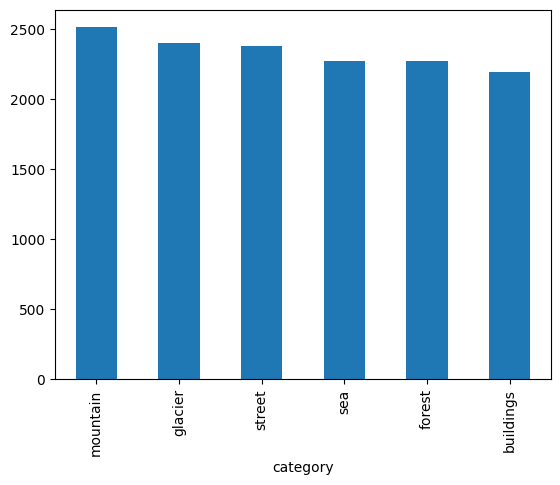

In [700]:
df['category'].value_counts().plot.bar();

Empezamos otra vez

In [701]:
import cv2

def read_data(path, image_width, image_height):

    X = []
    y = []

    # Listar carpetas desde EL path que te pasan
    folders = sorted(os.listdir(path))

    for folder in folders:
        folder_path = os.path.join(path, folder)

        if not os.path.isdir(folder_path):
            continue

        for file in sorted(os.listdir(folder_path)):
            file_path = os.path.join(folder_path, file)

            if not os.path.isfile(file_path):
                continue

            image = cv2.imread(file_path)
            if image is None:
                continue

            # BGR -> RGB (opcional pero recomendable)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Resize (cv2 usa (width, height))
            smallimage = cv2.resize(image, (image_width, image_height))

            X.append(smallimage)
            y.append(folder)

    X = np.array(X, dtype=np.uint8)
    y = np.array(y)

    return X, y

In [702]:
X_train, y_train = read_data(TRAIN_PATH, IMAGE_WIDTH, IMAGE_HEIGHT)
X_test, y_test = read_data(TEST_PATH, IMAGE_WIDTH, IMAGE_HEIGHT)

In [703]:
print("X:", X_train.shape)
print("y:", y_train.shape)
print("Categorias", np.unique(y_train))

X: (14034, 64, 64, 3)
y: (14034,)
Categorias ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


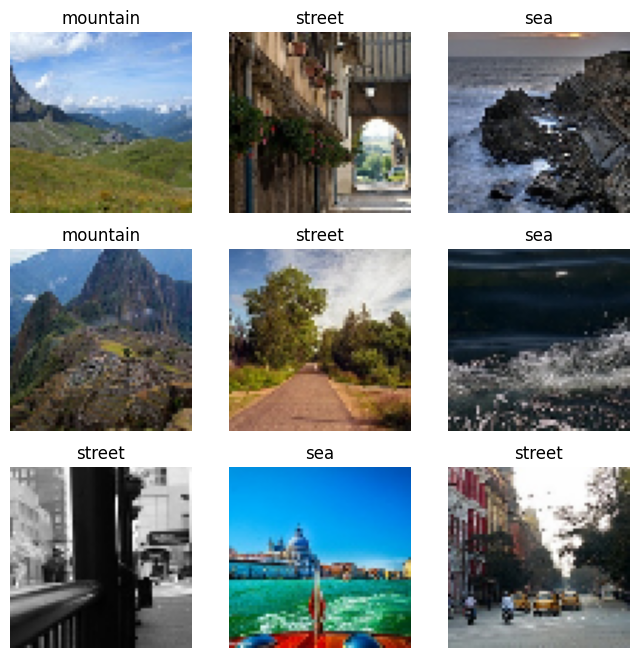

In [704]:
plt.figure(figsize=(8, 8))

for i in range(9):
    idx = random.randint(0, len(X_train) - 1)
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx])
    plt.title(y_train[idx])
    plt.axis("off")

plt.show()


In [705]:
print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0
Max: 255


In [706]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0.0
Max: 1.0


In [707]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [708]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [709]:
y_train_encoded

array([0, 5, 5, ..., 2, 0, 3], shape=(14034,))

In [710]:
import tensorflow as tf
from tensorflow import keras

class RandomGrayscale(keras.layers.Layer):
    def __init__(self, p=0.3):
        super().__init__()
        self.p = p

    def call(self, x, training=None):
        if training:
            do_gray = tf.random.uniform([]) < self.p
            gray = tf.image.rgb_to_grayscale(x)
            gray = tf.image.grayscale_to_rgb(gray)
            return tf.cond(do_gray, lambda: gray, lambda: x)
        return x

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [711]:
from tensorflow import keras

data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.05),
], name="aug")

model = keras.Sequential([
    keras.layers.Input(shape=IMAGE_SIZE),
    RandomGrayscale(p=0.3),  # 30% en gris
    data_augmentation,

    keras.layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(128, (3,3), activation='relu', padding="same"),
    keras.layers.MaxPooling2D(),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(6, activation="softmax"),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [712]:
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_grayscale_1              │ (None, 64, 64, 3)      │             0 │
│ (RandomGrayscale)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,934 (363.02 KB)

 Trainable params: 92,934 (363.02 KB)

 Non-trainable params: 0 (0.00 B)

In [713]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

mcheckpoint = ModelCheckpoint(
    "callback_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [714]:
history = model.fit(X_train,
         y_train_encoded,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         callbacks = [earlystop, mcheckpoint],
         validation_split = 0.2)

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - accuracy: 0.3245 - loss: 1.5403 - val_accuracy: 0.4564 - val_loss: 1.2739
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - accuracy: 0.4255 - loss: 1.3309 - val_accuracy: 0.4685 - val_loss: 1.4721
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - accuracy: 0.5028 - loss: 1.1836 - val_accuracy: 0.5957 - val_loss: 1.0355
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.5319 - loss: 1.1308 - val_accuracy: 0.5828 - val_loss: 1.0546
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - accuracy: 0.5498 - loss: 1.1063 - val_accuracy: 0.6263 - val_loss: 0.9753
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 128ms/step - accuracy: 0.5669 - loss: 1.0759 - val_accuracy: 0.6359 - val_loss: 0.9510
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.5815 - loss: 1.0425 - val_accuracy: 0.6605 - val_loss: 0.9050
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 123ms/step - accuracy: 0.5894 -

<Axes: >

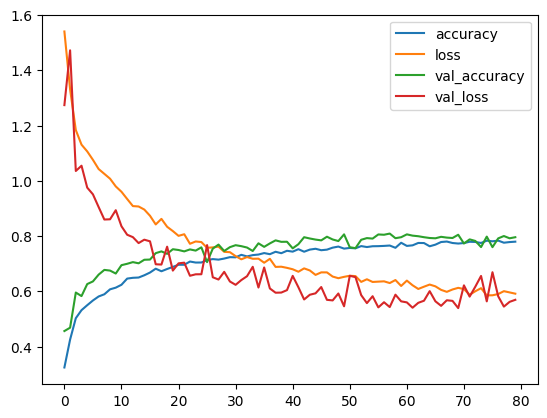

In [715]:
pd.DataFrame(history.history).plot()

In [716]:
results = model.evaluate(X_test, y_test_encoded)
results

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8103 - loss: 0.5319


[0.5319106578826904, 0.8103333115577698]

In [717]:
y_pred = model.predict(X_test)
y_pred

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


array([[9.94669259e-01, 1.62720353e-05, 2.15092485e-04, 3.52385796e-05,
        4.63076960e-03, 4.33290901e-04],
       [4.35731769e-01, 7.15173024e-04, 4.05541505e-04, 1.03069906e-04,
        5.65792085e-04, 5.62478602e-01],
       [9.75140393e-01, 3.54786025e-05, 4.68772487e-05, 8.09213452e-05,
        9.13941767e-04, 2.37824265e-02],
       ...,
       [1.75421461e-02, 9.19529051e-03, 4.09883149e-02, 5.83711684e-01,
        3.41523081e-01, 7.03953067e-03],
       [8.39231730e-01, 5.40575711e-04, 1.79914036e-03, 8.07234377e-04,
        4.35294732e-02, 1.14091888e-01],
       [3.83033641e-02, 9.97192785e-03, 4.12044137e-05, 2.13879366e-06,
        1.13993256e-05, 9.51669931e-01]], shape=(3000, 6), dtype=float32)

In [718]:
y_pred_labels = np.argmax(y_pred, axis=1)
y_pred_labels

array([0, 5, 0, ..., 3, 0, 5], shape=(3000,))

In [719]:
y_pred[0]

array([9.9466926e-01, 1.6272035e-05, 2.1509248e-04, 3.5238580e-05,
       4.6307696e-03, 4.3329090e-04], dtype=float32)

In [720]:
y_pred_labels[0]

np.int64(0)

In [721]:
# Predicciones
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Índices de errores
errors = np.where(y_pred != y_test_encoded)[0]

print("Número de errores:", len(errors))


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Número de errores: 569


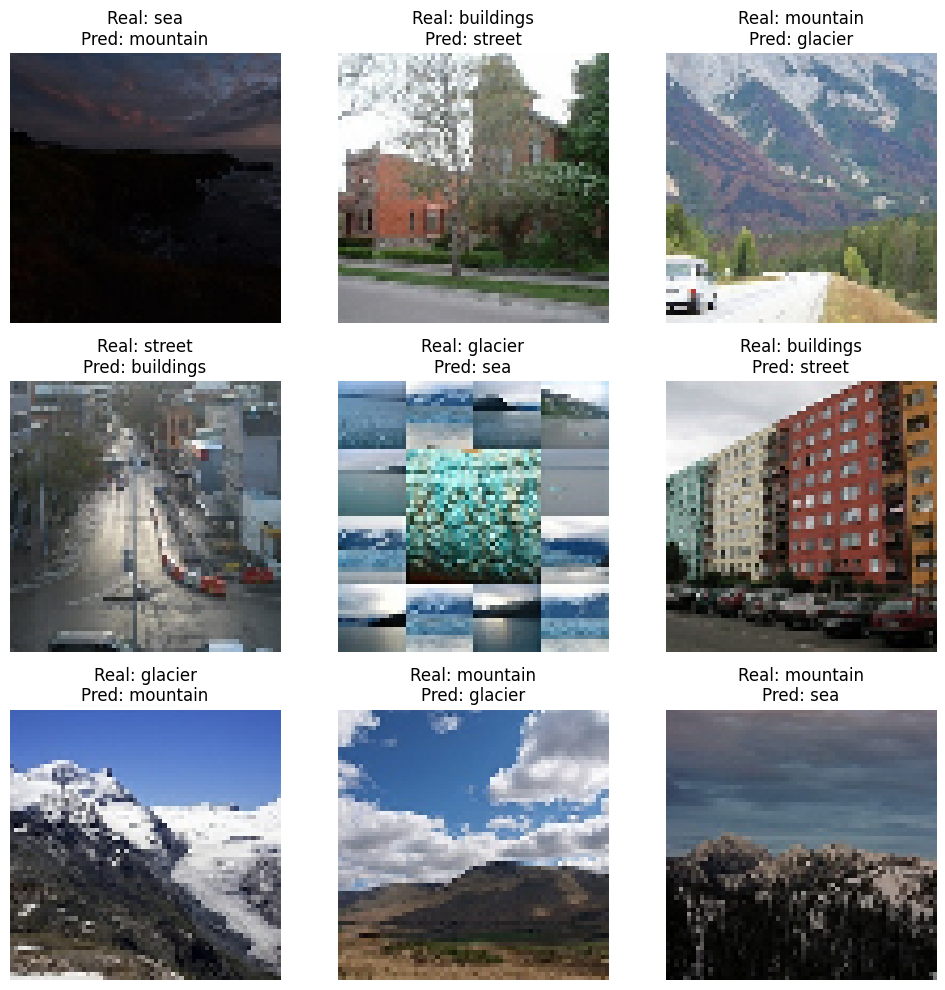

In [722]:
plt.figure(figsize=(10,10))

for i, idx in enumerate(random.sample(list(errors), min(9, len(errors)))):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx])
    true_label = encoder.inverse_transform([y_test_encoded[idx]])[0]
    pred_label = encoder.inverse_transform([y_pred[idx]])[0]
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


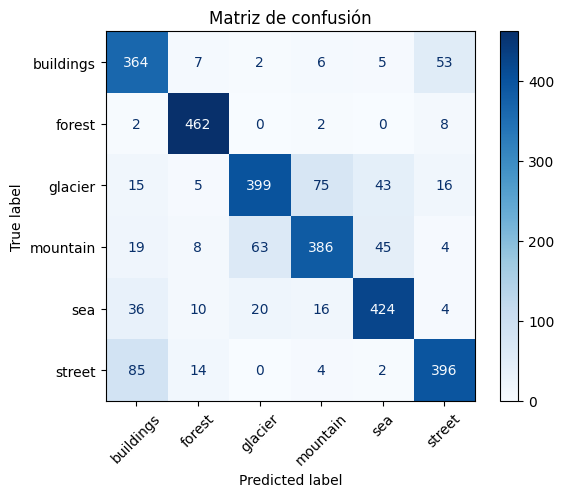

In [723]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_encoded, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión")
plt.show()


In [724]:
y_test_encoded.shape

(3000,)